In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [26]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [27]:
llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    temperature=0
)
def chat_node(state: ChatState):
    
    # take user query from state
    messages = state['messages']

    #send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [28]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

#add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot= graph.compile(checkpointer= checkpointer)

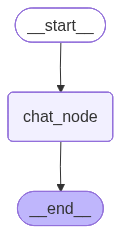

In [29]:
chatbot

In [30]:
#initial_state ={
    #'messages': [HumanMessage(content='What is the capital of india')]

#}
#chatbot.invoke(initial_state)['messages'][-1].content

In [32]:
thread_id = '1'

while True:
    user_message = input('Type here: ')
    print('User:', user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print('AI:', response['messages'][-1].content)

User: hi my name is Aastha
AI: Nice to meet you, Aastha. Is there something I can help you with or would you like to chat?
User: what is my name
AI: Your name is Aastha.
User: can you add 10 to aoo
AI: It seems like "aoo" is not a valid number. Could you please provide a valid number, and I'll be happy to add 10 to it?
User: can you add 10 to 100
AI: 100 + 10 = 110
User: now can you multiply yhe result with 3
AI: Multiplying 110 by 3:

110 × 3 = 330
User: bye


In [33]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is Aastha', additional_kwargs={}, response_metadata={}, id='16aa728f-4223-45bd-abe8-a598853bb170'), AIMessage(content='Nice to meet you, Aastha. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 42, 'total_tokens': 67, 'completion_time': 0.02858818, 'completion_tokens_details': None, 'prompt_time': 0.002179611, 'prompt_tokens_details': None, 'queue_time': 0.048251219, 'total_time': 0.030767791}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--257eef48-6047-48f7-9b02-0a10d9d12463-0', usage_metadata={'input_tokens': 42, 'output_tokens': 25, 'total_tokens': 67}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='ea10c74f-8103-48d1-9